In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pyscf import gto, dft, tdscf

import pyscf
import numpy as np
import qrunch as qc
from qrunch.chemistry.reduced_density_matrices.reduced_density_matrix_calculator import (
    ReducedDensityMatrixCalculator,
)
from pyscf import gto, scf, fci, mp, mcscf
import matplotlib.pyplot as plt

from qchem.utils import  (
    MoleculeData,
    get_hf_gse_from_mol,
    one_electron_integral_transform,
    two_electron_integral_transform
    )

from dmdm.interface import DMDM

qc.register_license_file("/home/flemming/Nextcloud/Cherimoya/training/master_cs/ms_project/code/qchem/license_fm.txt")

converged SCF energy = -76.0413817223861
Excited State energies (eV)
[ 8.63395595 10.31474735 10.97739649 12.10438912 12.6201002  12.80077447
 13.17816525 13.2401228  14.32995836 14.37720519]
Excitation energies (eV):
[ 8.63396039 10.31475265 10.97740213 12.10439534 12.62010668 12.80078105
 13.17817202 13.2401296  14.32996572 14.37721258]

Oscillator strengths:
[4.97461448e-02 4.19650020e-27 1.03180884e-01 5.46252753e-03
 2.79779258e-02 2.10567347e-04 3.65497449e-25 6.35494743e-04
 1.47473857e-01 1.67423498e-03]


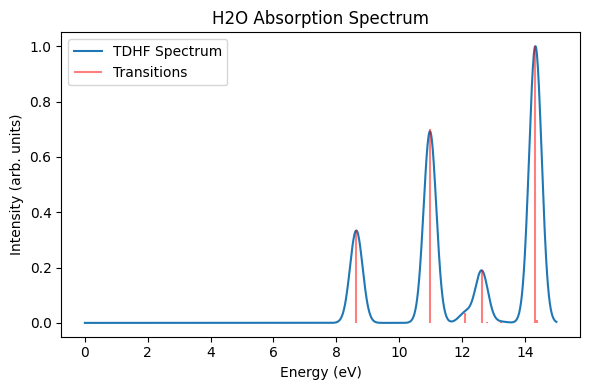

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pyscf import gto, scf, tdscf

# ----------------------------
# 1. Define molecule
# ----------------------------
mol = gto.M(
    atom='''
        O 0.000000 0.000000 0.000000
        H 0.000000 -0.757000 0.587000
        H 0.000000  0.757000 0.587000
    ''',
    basis='aug-cc-pVDZ',  # IMPORTANT for correct spectrum
    # basis='sto-3g',
    unit='Angstrom'
)

# ----------------------------
# 2. Hartree–Fock
# ----------------------------
mf = scf.RHF(mol)
mf.kernel()

# ----------------------------
# 3. Excited states (TDHF)
# ----------------------------
td = tdscf.TDHF(mf)
td.nstates = 10
td.kernel()

# ----------------------------
# 4. Extract data
# ----------------------------
hartree_to_ev = 27.2114

exc_energies_ev = td.e * hartree_to_ev
osc_strengths = td.oscillator_strength()

print("Excitation energies (eV):")
print(exc_energies_ev)

print("\nOscillator strengths:")
print(osc_strengths)

# ----------------------------
# 5. Build spectrum
# ----------------------------
def gaussian(x, mu, sigma):
    return np.exp(-(x - mu)**2 / (2 * sigma**2))

# energy grid
x = np.linspace(0, 15, 1000)  # eV

# broadening width (in eV)
sigma = 0.2

spectrum = np.zeros_like(x)

for E, f in zip(exc_energies_ev, osc_strengths):
    spectrum += f * gaussian(x, E, sigma)

# normalize (optional)
spectrum /= np.max(spectrum)

# ----------------------------
# 6. Plot
# ----------------------------
plt.figure(figsize=(6,4))
plt.plot(x, spectrum, label="TDHF Spectrum")

# stick spectrum
plt.vlines(exc_energies_ev, 0, osc_strengths/np.max(osc_strengths),
           color='red', alpha=0.5, label="Transitions")

plt.xlabel("Energy (eV)")
plt.ylabel("Intensity (arb. units)")
plt.title("H2O Absorption Spectrum")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from pyscf import gto, scf

# Define molecule (example: H2)
mol = gto.M(
    # atom = 'H 0 0 0; H 0 0 0.74',
    atom='''
    O 0 0 0
    H 0 -0.757 0.587
    H 0  0.757 0.587
    ''',
    basis = 'sto-3g',
    symmetry = True
)

# Run Restricted Hartree-Fock
mf = scf.RHF(mol)
hf_energy = mf.kernel()

print("HF Energy:", hf_energy)

converged SCF energy = -74.9630631297277
HF Energy: -74.96306312972766


In [ ]:
from pyscf import fci

# Create FCI solver
cisolver = fci.FCI(mol, mf.mo_coeff)

# Compute multiple states
nroots = 5  # number of states (ground + excited)
energies, wavefunctions = cisolver.kernel(nroots=nroots)

print("FCI energies:")
for i, e in enumerate(energies):
    print(f"State {i}: {e:.8f} Hartree")

FCI energies:
State 0: -75.01264712 Hartree
State 1: -74.51101100 Hartree
State 2: -74.41449059 Hartree
State 3: -74.25229371 Hartree
State 4: -74.01508113 Hartree


In [ ]:
import numpy as np

ground_energy = energies[0]
excitation_energies = energies - ground_energy

print("\nExcitation energies (Hartree):")
for i, e in enumerate(excitation_energies):
    print(f"Excited state {i}: {e:.6f}")

hartree_to_ev = 27.2114
excitation_energies_ev = excitation_energies * hartree_to_ev

print("\nExcitation energies (eV):")
for i, e in enumerate(excitation_energies_ev):
    print(f"Excited state {i}: {e:.6f}")


Excitation energies (Hartree):
Excited state 0: 0.000000
Excited state 1: 0.501636
Excited state 2: 0.598157
Excited state 3: 0.760353
Excited state 4: 0.997566

Excitation energies (eV):
Excited state 0: 0.000000
Excited state 1: 13.650221
Excited state 2: 16.276677
Excited state 3: 20.690281
Excited state 4: 27.145167


In [ ]:
from pyscf import mcscf

# 5. Alternative for larger systems: CASCI

# FCI scales exponentially, so for realistic systems:

# Define active space (example: 2 electrons in 2 orbitals)
ncas = 2
nelecas = 2

mc = mcscf.CASCI(mf, ncas, nelecas)

nroots = 5
mc.fcisolver.nroots = nroots

cas_energies = mc.kernel()[0]

print("CASCI energies:", cas_energies)


WARN: Mulitple states found in CASCI solver. First state is used to compute the Fock matrix and natural orbitals in active space.

CASCI state   0  E = -74.9643114016257  E(CI) = -1.66395567955998  S^2 = 0.0000000
CASCI state   1  E = -73.7704614179283  E(CI) = -0.470105695862529  S^2 = 0.0000000
CASCI energies: [-74.9643114  -73.77046142]


In [ ]:
from pyscf import tdscf

td = tdscf.TDHF(mf)
td.nstates = 5

td_energies = td.kernel()[0]

print("TDHF excitation energies (Hartree):", td_energies)

Excited State energies (eV)
[13.14433259 15.12259649 16.66339893 19.10437451 21.95333464]
TDHF excitation energies (Hartree): [0.48304532 0.55574518 0.61236862 0.70207282 0.80677017]


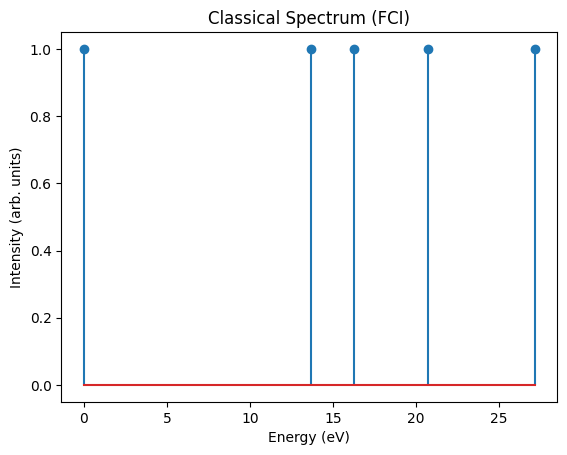

In [ ]:
import matplotlib.pyplot as plt

plt.stem(excitation_energies_ev, [1]*len(excitation_energies_ev))
plt.xlabel("Energy (eV)")
plt.ylabel("Intensity (arb. units)")
plt.title("Classical Spectrum (FCI)")
plt.show()

In [ ]:
excitation_energies_ev

array([ 0.        , 13.65022104, 16.27667655, 20.69028077, 27.14516724])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pyscf import gto, scf, mp, mcscf

# -------------------------
# 1. Define molecule
# -------------------------
mol = gto.M(
    atom='''
    O 0 0 0
    H 0 -0.757 0.587
    H 0  0.757 0.587
    ''',
    basis='sto-3g'
)

# -------------------------
# 2. RHF
# -------------------------
mf = scf.RHF(mol).run()

# -------------------------
# 3. MP2 → Natural orbitals
# -------------------------
mp2 = mp.MP2(mf).run()
noons, natorbs = mcscf.addons.make_natural_orbitals(mp2)

print("Natural occupation numbers:")
print(noons)

# -------------------------
# 4. Define CAS(4,4)
# -------------------------
ncas = 4
nelecas = 4

# Pick most correlated orbitals (by occupation)
idx = np.argsort(-noons)
cas_list = idx[:ncas]

print("Selected CAS orbitals:", cas_list)

# -------------------------
# 5. CASCI (FCI in active space)
# -------------------------
mc = mcscf.CASCI(mf, ncas=ncas, nelecas=nelecas)

# Use natural orbitals
mc.mo_coeff = natorbs

# Tell CASCI which orbitals are active
mc.natorb = False
mc.sort_mo(cas_list)

# Compute multiple states
nroots = 5
mc.fcisolver.nroots = nroots

energies = mc.kernel()[0]

# -------------------------
# 6. Excitation energies
# -------------------------
hartree_to_ev = 27.2114
excitation_energies = (np.array(energies) - energies[0]) * hartree_to_ev

# Remove ground state
excitation_energies = excitation_energies[1:]

print("Excitation energies (eV):")
print(excitation_energies)

# -------------------------
# 7. Build spectrum (equal intensity)
# -------------------------
def gaussian(x, mu, sigma):
    return np.exp(-(x - mu)**2 / (2 * sigma**2))

x = np.linspace(0, 15, 1000)
sigma = 0.2

spectrum = np.zeros_like(x)

for e in excitation_energies:
    spectrum += gaussian(x, e, sigma)

# -------------------------
# 8. Plot
# -------------------------
plt.plot(x, spectrum)
plt.xlabel("Energy (eV)")
plt.ylabel("Intensity (arb. units)")
plt.title("H2O CAS(4,4) Absorption Spectrum (Equal Intensities)")
plt.show()

converged SCF energy = -74.9630631297276
E(RMP2) = -74.9986299479474  E_corr = -0.0355668182197806
E(SCS-RMP2) = -75.003981716266  E_corr = -0.0409185865383464
Natural occupation numbers:
[1.99999738 1.9990192  1.99840475 1.98913534 1.98713572 0.01367057
 0.01263704]
Selected CAS orbitals: [0 1 2 3]

WARN: Mulitple states found in CASCI solver. First state is used to compute the Fock matrix and natural orbitals in active space.

CASCI state   0  E = -75.0085446614450  E(CI) = -6.33659863392384  S^2 = 0.0000000
CASCI state   1  E = -74.3668654556392  E(CI) = -5.69491942811798  S^2 = 2.0000000
CASCI state   2  E = -74.3647518793050  E(CI) = -5.69280585178383  S^2 = 2.0000000
CASCI state   3  E = -74.2053709585589  E(CI) = -5.53342493103771  S^2 = 0.0000000
CASCI state   4  E = -74.1761916323680  E(CI) = -5.50424560484682  S^2 = 2.0000000
Excitation energies (eV):
[17.46098954 17.51850291 21.8554809  22.64949122]


KeyboardInterrupt: 

In [ ]:
excitation_energies

array([17.46098954, 17.51850291, 21.8554809 , 22.64949122])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pyscf import gto, scf, dft, tddft, mp, mcscf

hartree_to_ev = 27.2114

# -------------------------
# 1. Molecule
# -------------------------

basis = "aug-cc-pVDZ" #'6-31g'
mol = gto.M(
    atom='''
    O 0 0 0
    H 0 -0.757 0.587
    H 0  0.757 0.587
    ''',
    basis=basis   # better than STO-3G
)

# -------------------------
# 2. RHF (for CASCI)
# -------------------------
mf = scf.RHF(mol).run()

# MP2 → natural orbitals
mp2 = mp.MP2(mf).run()
noons, natorbs = mcscf.addons.make_natural_orbitals(mp2)

# -------------------------
# 3. CASCI (FCI benchmark)
# -------------------------
ncas = 4
nelecas = 4

# Select orbitals by occupation
idx = np.argsort(-noons)
# cas_list = idx[:ncas]
cas_list = idx[1:5]

mc = mcscf.CASCI(mf, ncas=ncas, nelecas=nelecas)
mc.mo_coeff = natorbs
mc.sort_mo(cas_list)

mc.fcisolver.nroots = 6
fci_energies = np.array(mc.kernel()[0])

fci_exc = (fci_energies - fci_energies[0]) * hartree_to_ev
fci_exc = fci_exc[1:]  # remove ground state

# -------------------------
# 4. TDDFT (intensities)
# -------------------------
mf_dft = dft.RKS(mol)
mf_dft.xc = "b3lyp"
mf_dft.kernel()

td = tddft.TDDFT(mf_dft)
td.nstates = 6
td.kernel()

td_energies = np.array(td.e) * hartree_to_ev
td_osc = td.oscillator_strength()

# -------------------------
# 5. Match FCI energies with TDDFT intensities
# -------------------------
# Simple approach: assume same ordering
n = min(len(fci_exc), len(td_osc))

energies = fci_exc[:n]
osc = td_osc[:n]

# -------------------------
# 6. Build spectrum
# -------------------------
def gaussian(x, mu, sigma):
    return np.exp(-(x - mu)**2 / (2 * sigma**2))

x = np.linspace(0, 30, 1000)
sigma = 0.2

spectrum = np.zeros_like(x)

for e, f in zip(energies, osc):
    spectrum += f * gaussian(x, e, sigma)

# -------------------------
# 7. Plot
# -------------------------
plt.plot(x, spectrum, label="FCI (positions) + TDDFT (intensity)")

# Optional: show stick spectrum
plt.vlines(energies, 0, osc, color='red', alpha=0.5, label="Transitions")

plt.xlabel("Energy (eV)")
plt.ylabel("Intensity")
plt.title("H2O Absorption Spectrum (Benchmark Hybrid)")
plt.legend()
plt.show()

converged SCF energy = -76.0413817223861
E(RMP2) = -76.2632781238287  E_corr = -0.221896401442636
E(SCS-RMP2) = -76.2585175364315  E_corr = -0.217135814045419

WARN: Mulitple states found in CASCI solver. First state is used to compute the Fock matrix and natural orbitals in active space.

CASCI state   0  E = -76.0877613671283  E(CI) = -6.41048189367103  S^2 = 0.0000000
CASCI state   1  E = -75.3166178928779  E(CI) = -5.63933841942068  S^2 = 2.0000000
CASCI state   2  E = -75.3108105568726  E(CI) = -5.63353108341542  S^2 = 2.0000000
CASCI state   3  E = -75.2057259518020  E(CI) = -5.52844647834473  S^2 = 0.0000000
CASCI state   4  E = -75.1952031796100  E(CI) = -5.51792370615277  S^2 = 2.0000000
CASCI state   5  E = -75.1337218279831  E(CI) = -5.45644235452585  S^2 = 0.0000000
converged SCF energy = -76.4445445693651


KeyboardInterrupt: 

In [ ]:
td_energies

array([ 6.90450746,  8.35196865,  9.08894586, 10.24665319, 10.51397305,
       11.09115546])

In [ ]:
energies

array([20.98389354, 21.14191928, 24.0014185 , 24.28775786, 25.96075152])

In [ ]:
# Define the molecule
molecule_name = "H2O"
active_space = "minimal"
molecule = MoleculeData.molecules[molecule_name]["coords"]

# Define the basis
basis = "sto-3g"

# Define the active space
num_active_orbs = MoleculeData.molecules[molecule_name][active_space]["num_active_orbs"]
num_active_alpha_electrons = MoleculeData.molecules[molecule_name][active_space]["num_active_alpha_electrons"]

In [ ]:
molecule

[('O', 0.0, 0.0, 0.1035174918),
 ('H', 0.0, 0.7955612117, -0.4640237459),
 ('H', 0.0, -0.7955612117, -0.4640237459)]

In [ ]:
num_active_alpha_electrons

2

In [ ]:
natorbs[:num_active_orbs, :num_active_orbs].shape

(4, 4)

In [ ]:
# Get the HF ground state energy --> ground truth
# fci_gse, fci_vec = get_hf_gse_from_mol(molecule, basis)
# mol = gto.M(
# atom=molecule,
# basis=basis,
# unit='Angstrom',
# )

mol = gto.M(
    atom='''
    C  0.000000  1.397680  0.000000
    C  1.210380  0.698840  0.000000
    C  1.210380 -0.698840  0.000000
    C  0.000000 -1.397680  0.000000
    C -1.210380 -0.698840  0.000000
    C -1.210380  0.698840  0.000000
    H  0.000000  2.490000  0.000000
    H  2.160000  1.245000  0.000000
    H  2.160000 -1.245000  0.000000
    H  0.000000 -2.490000  0.000000
    H -2.160000 -1.245000  0.000000
    H -2.160000  1.245000  0.000000
    ''',
    basis='sto-3g', # Small basis for speed in example
    symmetry=True,
    verbose=0
)


hf_energy = mol.RHF().run()
moller_plesset = mp.MP2(hf_energy).run()
noons, natorbs = mcscf.addons.make_natural_orbitals(moller_plesset)
cisolver = fci.FCI(mol, natorbs)
fci_gse, fci_vec = cisolver.kernel()
print(f"E(FCI) = {fci_gse}")

KeyboardInterrupt: 

In [ ]:
fci_rdm1, fci_rdm2, fci_rdm3, fci_rdm4 = fci.rdm.make_dm1234('FCI4pdm_kern_sf', fci_vec, fci_vec, 7, 4)
fci_rdm1, fci_rdm2, fci_rdm3, fci_rdm4 = fci.rdm.reorder_dm1234(fci_rdm1, fci_rdm2, fci_rdm3, fci_rdm4) # comes in a different orientation.
h_mo = one_electron_integral_transform(natorbs, mol.intor("int1e_kin") + mol.intor("int1e_nuc"))
g_mo = two_electron_integral_transform(natorbs, mol.intor("int2e"))#

In [ ]:
g_mo.shape

(7, 7, 7, 7)

In [ ]:
natorbs.shape

(7, 7)

In [ ]:
dmdm = DMDM(
        h_mo,
        g_mo,
        0,
        7,
        0,
        4,
        fci_rdm1,
        rdm2=fci_rdm2,
        rdm3=fci_rdm3,
        rdm4=fci_rdm4,
        # print_level=3,
    )

In [ ]:
x, y, z = mol.intor('int1e_r', comp=3)
MO_DM = [one_electron_integral_transform(natorbs, x), one_electron_integral_transform(natorbs, y), one_electron_integral_transform(natorbs, z)]

exc_energies = dmdm.get_excitation_energies()
osc_strengths = dmdm.get_oscillator_strength(MO_DM)

print("Excitation energies (a.u.): ", exc_energies)
print("Oscillator strengths: ", osc_strengths)

idx, max(abs(grad active)): 84 3.4436396109886784
Smallest Hessian eigenvalue: (-1.464747897097241+0j)
Smallest diagonal element in the metric: 0.9702708080204958
Excitation energies (a.u.):  [4.06572876e-02 5.81948756e-02 1.93613228e-01 2.31197224e-01
 2.98162371e-01 6.25489586e-01 7.20181826e-01 7.85338278e-01
 9.15816264e-01 9.38135822e-01 1.48489833e+00 1.49685225e+00
 1.53127240e+00 1.56488404e+00 1.57450177e+00 1.58338814e+00
 1.58903616e+00 3.49154943e+00 3.99796347e+00 4.00190997e+00
 1.93688498e+01 1.99707831e+01 2.01111455e+01 2.01349009e+01
 2.01696337e+01 2.02547754e+01 2.05930039e+01 2.06982474e+01
 2.07191940e+01 2.07449476e+01 2.08794595e+01 2.10000271e+01
 2.20516522e+01 2.20627589e+01 2.22897435e+01 2.22961020e+01
 2.26504981e+01 2.26574902e+01 2.26967911e+01 2.27090795e+01
 2.27863018e+01 2.27881396e+01 2.28345933e+01 2.28400707e+01
 2.28648004e+01 2.28817441e+01 2.49392238e+01 2.50002599e+01
 2.55168736e+01 2.55212471e+01 4.35703524e+01 4.42957071e+01
 4.44078151e+01

In [ ]:
exc_energies.shape

(65,)

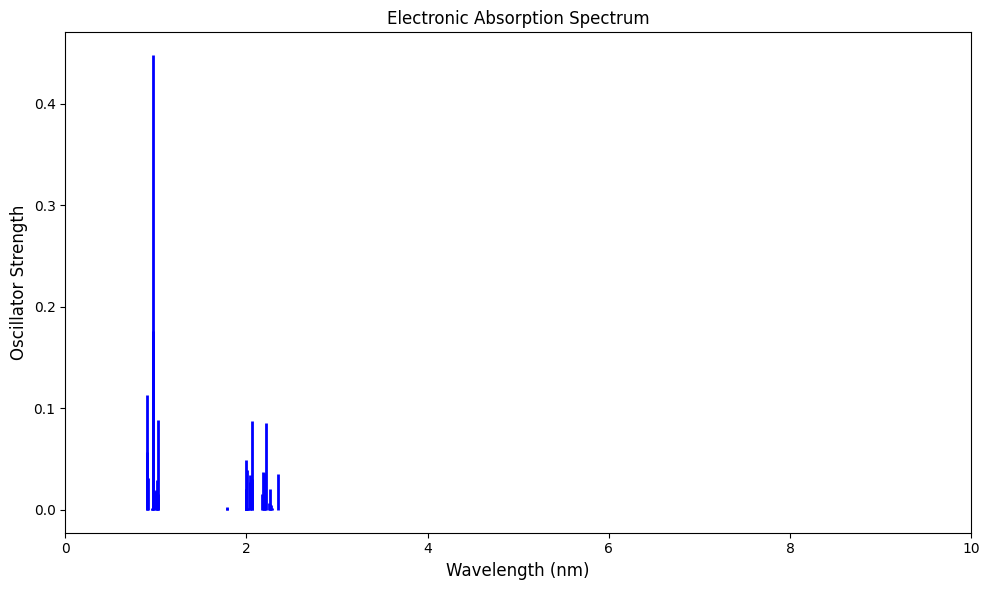

In [ ]:
# Convert Hartree to eV (1 Hartree = 27.2114 eV)
hartree_to_ev = 27.2114
energies_ev = np.array(exc_energies) * hartree_to_ev

# Convert to wavelength (nm) for UV-Vis spectra
# E(eV) = 1239.84 / λ(nm)
wavelengths_nm = 1239.84 / energies_ev

# Create stick spectrum
plt.figure(figsize=(10, 6))
for i, (wl, osc) in enumerate(zip(wavelengths_nm, osc_strengths)):
    plt.vlines(wl, 0, osc, colors='blue', linewidth=2)
    # plt.text(wl, osc*1.1, f'{i+1}', ha='center', fontsize=9)

plt.xlim(0, 10)

plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Oscillator Strength', fontsize=12)
plt.title('Electronic Absorption Spectrum')
plt.tight_layout()
plt.show()

In [ ]:
def plot_spectrum(energies_ev, osc_strengths, sigma_eV=0.3, xlim_nm=(150, 800), title="UV-Vis Spectrum (HF/CIS)"):
    wl_plot = np.linspace(xlim_nm[0], xlim_nm[1], 1000)
    energy_plot = ev_to_wl / wl_plot
    
    spectrum_intensity = np.zeros_like(wl_plot)
    
    for e_ev, f in zip(energies_ev, osc_strengths):
        gaussian = np.exp(-((energy_plot - e_ev)**2) / (2 * sigma_eV**2))
        spectrum_intensity += f * gaussian
    
    max_val = np.max(spectrum_intensity)
    if max_val > 0:
        spectrum_intensity /= max_val
    
    plt.figure(figsize=(10, 6))
    plt.plot(wl_plot, spectrum_intensity, color='blue', linewidth=2, label='Simulated')
    
    for wl, f in zip(wavelengths_nm, osc_strengths):
        if f > 0.01:
            plt.axvline(x=wl, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    plt.xlabel('Wavelength (nm)', fontsize=12)
    plt.ylabel('Relative Intensity (a.u.)', fontsize=12)
    plt.title(title, fontsize=14)
    plt.xlim(xlim_nm[1], xlim_nm[0])
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    
    filename = 'water_spectrum_hf.png'
    plt.savefig(filename, dpi=300)
    print(f"\nSpectrum saved to: {filename}")
    plt.show()

In [ ]:
# Convert units
hartree_to_ev = 27.2114
ev_to_wl = 1239.84

energies_ev = exc_energies_hartree * hartree_to_ev
wavelengths_nm = ev_to_wl / energies_ev

(7, 7)

In [ ]:
plot_spectrum(energies_ev, osc_strengths, sigma_eV=0.3)